In [1]:
import os
from pathlib import Path

import hydra
from hydra.utils import instantiate
import numpy as np
import matplotlib.pyplot as plt

from navsim.common.dataloader import SceneLoader
from navsim.common.dataclasses import SceneFilter, SensorConfig

from navsim.visualization.plots import plot_bev_with_agent
from navsim.agents.transfuser.transfuser_agent import TransfuserAgent
from navsim.agents.transfuser.transfuser_config import TransfuserConfig
from navsim.visualization.plots import plot_cameras_frame
import matplotlib.pyplot as plt
from navsim.agents.deepseek.gpt_utils import pose_to_vel_cur

SPLIT = "test" 
FILTER = "all_scenes"
FILTER = "navtest"

hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
cfg = hydra.compose(config_name=FILTER)
scene_filter: SceneFilter = instantiate(cfg)
openscene_data_root = Path(os.getenv("OPENSCENE_DATA_ROOT"))

scene_loader = SceneLoader(
    openscene_data_root / f"navsim_logs/{SPLIT}",
    openscene_data_root / f"sensor_blobs/{SPLIT}",
    scene_filter,
    sensor_config=SensorConfig.build_all_sensors(),
)

/opt/conda/envs/test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_6451/1453722712.py:23: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../navsim/planning/script/config/common/train_test_split/scene_filter")
Loading logs: 100%|██████████| 136/136 [00:05<00:00, 26.75it/s]


## Individual Scene

In [2]:
agent = TransfuserAgent(TransfuserConfig(), 1.0, "/home/ubuntu/project_ws/navsim/navsim/agents/transfuser/transfuser_seed_0.ckpt")
agent.initialize()

In [ ]:
chal_failures = ['75151361dbe658bb', 'a90de87b906d51e8', '3e11d77a9aca5bb7', '3be53588a286557f', '97c09fe94495563a', '69f50b1f6c4d5f4b', '277cdfc9479e52c4', 'b435be7b7b1b5dd4']
frame_idx = 3

for token in chal_failures:
    scene = scene_loader.get_scene_from_token(token)
    fig, ax = plot_cameras_frame(scene,frame_idx)


In [6]:
scene.get_history_trajectory()

Trajectory(poses=array([[-12.27001322,   0.35191599,  -0.07117605],
       [ -8.04207607,   0.14765577,  -0.03978339],
       [ -3.92633921,   0.03854591,  -0.01521032],
       [  0.        ,   0.        ,   0.        ]]), trajectory_sampling=TrajectorySampling(num_poses=4, time_horizon=2.0, interval_length=0.5))



[[ 1.4279351e-02 -5.6083337e-04  4.1150753e-03]
 [ 1.8548693e-01 -8.9310016e-03 -9.5010683e-04]
 [ 6.6080594e-01 -7.8067649e-03 -2.1880306e-03]
 [ 1.4454471e+00 -1.5390102e-02 -6.7444784e-03]
 [ 2.5055487e+00 -1.2824081e-02 -1.3526900e-03]
 [ 3.8186877e+00 -9.7418092e-03 -6.6407868e-03]
 [ 5.4047532e+00 -4.5033200e-03 -1.2668755e-02]
 [ 7.2319322e+00 -1.2515549e-02 -8.3846217e-03]]


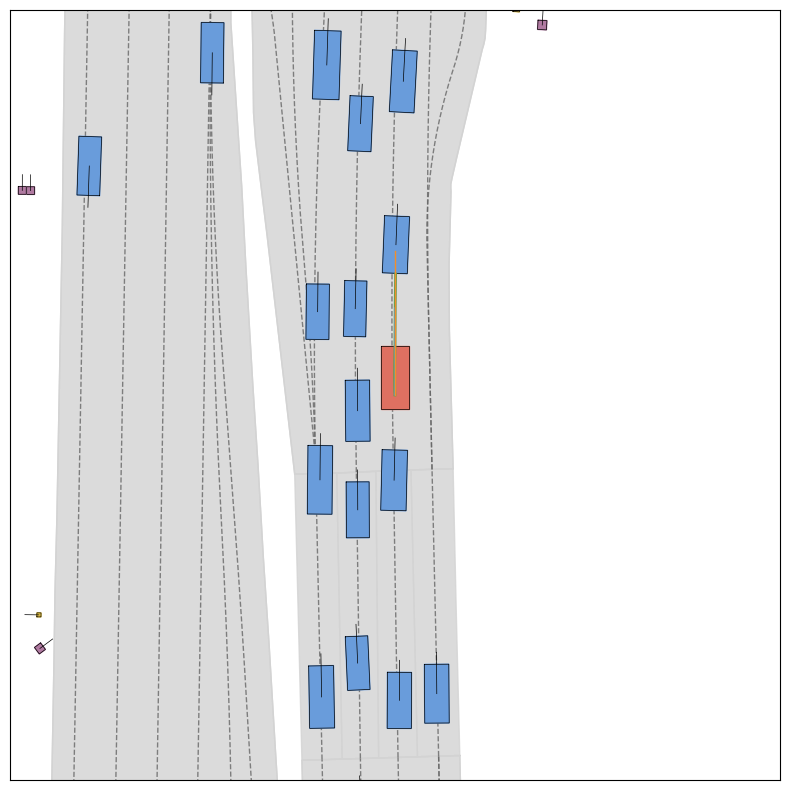

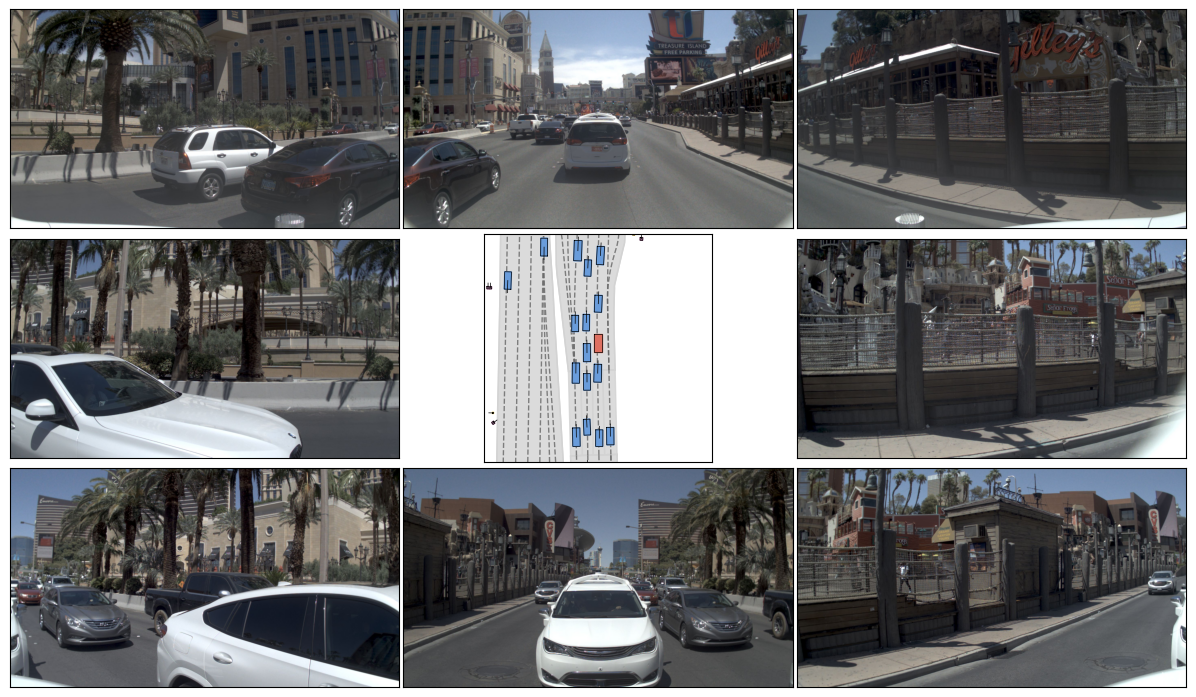

In [7]:
# token = np.random.choice(scene_loader.tokens)
token ="25cdf7dee0d25a66"
token = "b75644dcc9ca58fe"
trajectory = [[1.35, 0.0, 0.0], [3.5500000000000003, 0.0, 0.0], [6.425000000000001, 0.0, 0.0], [10.025, 0.0, 0.0], [14.35, 0.0, 0.0], [18.725, 0.0, 0.0], [22.675, 0.0, 0.0], [26.425, 0.0, 0.0]]
trajectory = [[1.5, 0.0, 0.0], [3.0, 0.0, 0.0], [4.5, 0.0, 0.0], [6.0, 0.0, 0.0], [7.5, 0.0, 0.0], [9.0, 0.0, 0.0], [10.5, 0.0, 0.0], [12.0, 0.0, 0.0]]
scene = scene_loader.get_scene_from_token(token)
frame_idx = scene.scene_metadata.num_history_frames - 1 # current frame

# fig, ax = plot_bev_with_agent(scene=scene, agent=agent)
fig, ax = plot_bev_with_agent(scene=scene, agent=agent, traj=np.array(trajectory))
fig, ax = plot_cameras_frame(scene,frame_idx)

img = scene_loader.get_agent_input_from_token(token).cameras[-1].cam_f0.image
imgl = scene_loader.get_agent_input_from_token(token).cameras[-1].cam_l0.image
imgr = scene_loader.get_agent_input_from_token(token).cameras[-1].cam_r0.image
scene_loader.get_agent_input_from_token(token).cameras
poses = agent.compute_trajectory(scene.get_agent_input())
print(poses.poses)
# plt.figure(figsize = (18,18))
# plt.imshow(img)
# plt.axis("off")
# plt.show()
# plt.figure(figsize = (18,18))
# plt.imshow(imgl)
# plt.axis("off")
# plt.show()
# plt.figure(figsize = (18,18))
# plt.imshow(imgr)
# plt.axis("off")
# plt.show()

In [ ]:
tft = ["214abdb588465704", "cd72b9f6b03f5f41", "384def2e3f9657f6", "6b8daf3b57175e70", "7a7e8074ee5c5389", "6704953640e55b83", "b9182baaae3b5ab2", "e7cfffa4e8dd53a8", "458ab847ffa957e8", "97c09fe94495563a"]
challenging = ["a90de87b906d51e8", "3be53588a286557f", "ba86ae71bc105215", "d26771df718251d1", "3e11d77a9aca5bb7", "25cdf7dee0d25a66", "97c09fe94495563a", "a41a728fda515594", "69f50b1f6c4d5f4b", "a4a08c828e87562c", "b762ea96cfa75157", "384def2e3f9657f6", "4024c1a4953e57a7", "b435be7b7b1b5dd4", "277cdfc9479e52c4", "ff1a4e51e3f558ce", "75151361dbe658bb"]
random = ["83c7a6c3c0b15b36",  "43066c8c8e325fcf",  "6b0ff02cbbf25aa3",  "2959d5dbe8235765",  "b4aeb4bbd9035964",  "c2a93dd3494b5702",  "6b8daf3b57175e70",  "26e7a31dd615509c",  "6922b2ea23cd51a3",  "ab313e9e217c581b",  "458ab847ffa957e8",  "4566a3d9b5e95d9b",  "96f6cde1205e5865",  "016d6a913efa5ff1",  "e194cef299cf5264",  "b02be1e28abb59f1",  "7f62e2a838405444",  "b619e01b47775ec5",  "bc2fe3314b345c63",  "92bbb17b853a5aa2",  "36077daf1cda5d05",  "6fcec1c4552351ed",  "6704953640e55b83",  "d4ac0a1865ac5c25",  "eb5989e21dc35a47",  "b9182baaae3b5ab2",  "9b7108902e7158d6",  "b9633d9afd4356a8",  "e7cfffa4e8dd53a8",  "76b3e192b5e45727",  "e0e228212a655d7f"]

The function `plot_bev_frame` takes a `Scene` and index of the step to visualize (history or future). 

In [ ]:
from navsim.visualization.plots import plot_bev_frame

fig, ax = plot_bev_frame(scene, frame_idx)
plt.show()

In [ ]:
from navsim.agents.deepseek.gpt_agent import GPTAgent
from navsim.agents.deepseek.gpt_config import GPTConfig
from navsim.visualization.plots import plot_bev_with_agent

agent = GPTAgent(GPTConfig)
agent.initialize()

fig, ax = plot_bev_with_agent(scene, agent)
plt.show()

## Evaluate individual Scenarios with Agents and so


In [1]:
import os
import hydra
import numpy as np
import lzma
import pickle
import matplotlib.pyplot as plt

from pathlib import Path
from hydra.utils import instantiate
from navsim.evaluate.pdm_score import pdm_score
from navsim.visualization.plots import plot_cameras_frame
from navsim.visualization.plots import plot_bev_with_agent
from navsim.common.dataclasses import SceneFilter, SensorConfig
from navsim.common.dataloader import SceneLoader, MetricCacheLoader
from navsim.planning.metric_caching.metric_cache import MetricCache
from navsim.agents.transfuser.transfuser_agent import TransfuserAgent
from navsim.agents.transfuser.transfuser_config import TransfuserConfig
from navsim.planning.simulation.planner.pdm_planner.scoring.pdm_scorer import PDMScorer
from navsim.planning.simulation.planner.pdm_planner.simulation.pdm_simulator import PDMSimulator

SPLIT = "test" 
FILTER = "all_scenes"
FILTER = "navtest"

CONFIG_PATH = "config/pdm_scoring"
CONFIG_NAME = "run_special_pdm_score" # in this file might need to change the split between eval_random and eval_challenging

hydra.initialize(config_path="../navsim/planning/script/config/pdm_scoring")
cfg = hydra.compose(config_name=CONFIG_NAME)

/opt/conda/envs/test/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_10279/1536461171.py:28: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  hydra.initialize(config_path="../navsim/planning/script/config/pdm_scoring")


In [17]:
scene_loader = SceneLoader(
    sensor_blobs_path=None,
    data_path=Path(cfg.navsim_log_path),
    scene_filter=instantiate(cfg.train_test_split.scene_filter),
    sensor_config=SensorConfig.build_no_sensors(),
)
log_names =[]
tokens = []

for log_file, tokens_list in scene_loader.get_tokens_list_per_log().items():
    log_names.append(log_file)
    tokens.append(tokens_list)

split_up = [token for sublist in tokens for token in sublist]
simulator: PDMSimulator = instantiate(cfg.simulator)
scorer: PDMScorer = instantiate(cfg.scorer)
assert (simulator.proposal_sampling == scorer.proposal_sampling), "Simulator and scorer proposal sampling has to be identical"
agent = TransfuserAgent(TransfuserConfig(), 1.0, "/home/ubuntu/project_ws/navsim/navsim/agents/transfuser/transfuser_seed_0.ckpt")
agent.initialize()

metric_cache_loader = MetricCacheLoader(Path(cfg.metric_cache_path))
scene_filter: SceneFilter = instantiate(cfg.train_test_split.scene_filter)
scene_filter.log_names = log_names
scene_filter.tokens =  split_up
scene_loader = SceneLoader(
    sensor_blobs_path=Path(cfg.sensor_blobs_path),
    data_path=Path(cfg.navsim_log_path),
    scene_filter=scene_filter,
    sensor_config=agent.get_sensor_config(),
)

token ="83c7a6c3c0b15b36"
print(scene_loader.tokens)
scene = scene_loader.get_scene_from_token(token)
metric_cache_path = metric_cache_loader.metric_cache_paths[token]
with lzma.open(metric_cache_path, "rb") as f:
    metric_cache: MetricCache = pickle.load(f)

agent_input = scene_loader.get_agent_input_from_token(token)
trajectory = agent.compute_trajectory(agent_input)

pdm_result = pdm_score(
                metric_cache=metric_cache,
                model_trajectory=trajectory,
                future_sampling=simulator.proposal_sampling,
                simulator=simulator,
                scorer=scorer,
            )

Loading logs: 100%|██████████| 38/38 [00:01<00:00, 19.15it/s]


['b4aeb4bbd9035964', 'b3de35a12e36586c', 'e0164d976037592c', '3e8c8729205850ab', '6fcec1c4552351ed', '96f6cde1205e5865', '6704953640e55b83', '26e7a31dd615509c', '9b7108902e7158d6', 'b619e01b47775ec5', '2959d5dbe8235765', 'e194cef299cf5264', '8ddb6763987051ba', '6922b2ea23cd51a3', '76b3e192b5e45727', '6b0ff02cbbf25aa3', 'c2a93dd3494b5702', '13ba9275e341525b', '72c898c5c6a45939', 'a164681774715cea', '83c7a6c3c0b15b36', 'df8bff51c1d95e09', '48321ca34be254e5', '8eda03e314a456a4', 'f2e0d7e15fa253f0', '6b8daf3b57175e70', '7f9f4661a4875959', 'bc2fe3314b345c63', '6c321000d6c0527a', 'b9182baaae3b5ab2', '784c48e2a44c5036', 'e7cfffa4e8dd53a8', '92bbb17b853a5aa2', '36077daf1cda5d05', 'b02be1e28abb59f1', 'b9633d9afd4356a8', '7f62e2a838405444', '9215943615c45afd', '80957a180a325353', '7a7e8074ee5c5389', 'e0e228212a655d7f', 'd4ac0a1865ac5c25', 'eb5989e21dc35a47', 'ab313e9e217c581b', 'e49a1ec4a5af596b', '4566a3d9b5e95d9b', '458ab847ffa957e8', '016d6a913efa5ff1', '1b35b775c4a95647', '43066c8c8e325fcf']

In [18]:
pdm_result

PDMResults(no_at_fault_collisions=1.0, drivable_area_compliance=1.0, ego_progress=0.9993322059642443, time_to_collision_within_bound=1.0, comfort=1.0, driving_direction_compliance=1.0, score=0.9997217524851019)